# Rain in Australia - Preprocessing Pipeline

**Target** : To check if `Rain Tomorrow (YES/NO)` 

## Imports 

- **pandas / numpy**: core data manipulation
- **sklearn.impute.IterativeImputer**: MICE-based imputation (requires enabling the experimental flag first)
- **matplotlib / seaborn**: visualization

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

## Load Data & inspection

Before doning anything we need to see the data and get a clear picture of what we are dealing with like :
- data shape
- data types
- missing values and its percentage

This will help us to determine the better technique that should be applied 

In [71]:
df = pd.read_csv(r'D:\GitHub\Preprocessing_project\weatherAUS.csv')
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [72]:
df.shape

(145460, 23)

In [73]:
# Check for the numeric columns if have "object" dtype then there is a problem with it
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

In [74]:
# Now with missing value analysis
miss_count = df.isnull().sum()
miss_pct = (miss_count/df.shape[0]*100).round(3)

miss_df= pd.DataFrame({'Missing Count':miss_count,'Missing Percentage':miss_pct})
miss_df=miss_df[miss_df['Missing Count']>0].sort_values('Missing Count',ascending=False)

miss_df

,Missing Count,Missing Percentage
Sunshine,69835,48.010
Evaporation,62790,43.167
Cloud3pm,59358,40.807
Cloud9am,55888,38.422
Pressure9am,15065,10.357
Pressure3pm,15028,10.331
WindDir9am,10566,7.264
WindGustDir,10326,7.099
WindGustSpeed,10263,7.056
Humidity3pm,4507,3.098


## Advanced Imputation

The strategy is to :
- Group Median by Location for > 35% Missing
- MICE (IterativeImputer) for > 15% Missing
- Mode by Location for Categorial
- Delete the Rows From the affected training data (`Rain Tomorrow` Column)

### 1.Group Median by location
**Columns:** `Evaporation`, `Sunshine`, `Cloud9am`, `Cloud3pm`

In [75]:
h_miss_cols = ['Evaporation', 'Sunshine', 'Cloud9am', 'Cloud3pm']

print("Missing Counts Before : ")
print(df[h_miss_cols].isnull().sum())
print()

for col in h_miss_cols:
    df[col] = df.groupby('Location')[col].transform( lambda x :x.fillna(x.median()) )

    #But if the Location has now data the median will be NaN then we need to handle this
    rem_data = df[col].isnull().sum()
    if rem_data >0:
        df[col] = df[col].fillna(df[col].median())
        print(f'==>{col} used global median for : {rem_data} values')


print("\nMissing Counts After : ")
print(df[h_miss_cols].isnull().sum())    

Missing Counts Before : 
Evaporation    62790
Sunshine       69835
Cloud9am       55888
Cloud3pm       59358
dtype: int64

==>Evaporation used global median for : 45511 values
==>Sunshine used global median for : 53169 values
==>Cloud9am used global median for : 34967 values
==>Cloud3pm used global median for : 34967 values

Missing Counts After : 
Evaporation    0
Sunshine       0
Cloud9am       0
Cloud3pm       0
dtype: int64


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keep

### 2.MICE (IterativeImputer)
**Columns:** `All Remaining Numerical Columns`

#### How it works :
1. We will start with fill missing by median (because weather vars can be right-skewed)
2. For each column that have missing values a regression model is trained using all other columns as input
3. The model predicts the missing values
4. go to next column and reapeat the process
5. After finish all columns iterate again until values gather 

In [76]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
mice_cols = [c for c in num_cols if df[c].isnull().sum() > 0]

print("Columns & Missing Counts Before : ")
print(df[mice_cols].isnull().sum())

mice_imputer = IterativeImputer(
    max_iter= 10 , 
    random_state= 42 ,
    initial_strategy='median', 
    imputation_order= 'roman' #from left to right for deterministic behaviour
)
print("\nRunning.....")
df[mice_cols] = mice_imputer.fit_transform(df[mice_cols])

print("\nColumns & Missing Counts After : ")
print(df[mice_cols].isnull().sum())

Columns & Missing Counts Before : 
MinTemp           1485
MaxTemp           1261
Rainfall          3261
WindGustSpeed    10263
WindSpeed9am      1767
WindSpeed3pm      3062
Humidity9am       2654
Humidity3pm       4507
Pressure9am      15065
Pressure3pm      15028
Temp9am           1767
Temp3pm           3609
dtype: int64

Running.....

Columns & Missing Counts After : 
MinTemp          0
MaxTemp          0
Rainfall         0
WindGustSpeed    0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Temp9am          0
Temp3pm          0
dtype: int64


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


### 3.Mode by Location for Categorial
**Columns:** `WindGustDir`, `WindDir9am`, `WindDir3pm`, `RainToday`

In [77]:
cat_cols = ['WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']
print("Missing Counts Before : ")
print(df[cat_cols].isnull().sum())
print()

for col in cat_cols:
    df[col] = df.groupby('Location')[col].transform( lambda x :x.fillna(x.mode()[0] if not x.mode().empty else 'NaN' ) )

    # also here same problem if whole location has no data
    rem_data = df[col].isnull().sum()
    if rem_data >0:
        df[col] = df[col].fillna(df[col].mode()[0])
        print(f'==>{col} used global mode for : {rem_data} values')
        
print("/nMissing Counts After : ")
print(df[cat_cols].isnull().sum())

Missing Counts Before : 
WindGustDir    10326
WindDir9am     10566
WindDir3pm      4228
RainToday       3261
dtype: int64

/nMissing Counts After : 
WindGustDir    0
WindDir9am     0
WindDir3pm     0
RainToday      0
dtype: int64


### 4.Delete the Rows Missing in `RainTomorrow`

In [78]:
row_before=len(df)
df.dropna(subset=['RainTomorrow'],inplace=True)
print(f"Dropped {row_before-len(df)} rows form RainTomorrow ({(row_before-len(df))/row_before*100:.2f}) % loss)")

Dropped 3267 rows form RainTomorrow (2.25) % loss)


### Now Checking Missing values & Dataset Shape

In [79]:
print(f'Total missing values: {df.isnull().sum().sum()}')
print(f'shape: {df.shape}')

Total missing values: 0
shape: (142193, 23)


## Handling Outliers

In [80]:
num_cols =  df.select_dtypes(include=np.number).columns.tolist()
outlier_df=[]

for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1 
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    n_below = (df[col] < lower_bound).sum()
    n_above = (df[col] > upper_bound).sum()
    n_tot   = n_below + n_above
    outlier_df.append({
        'Column':col,
        'Q1' : round(q1,2),
        'Q3' : round(q3,2),
        'Lower Bound': round(lower_bound, 2),
        'Upper Bound': round(upper_bound, 2),
        'Number Below': n_below,
        'Number Above': n_above,
        'Total Outliers': n_tot,
        'Outlier Percentage': round(n_tot/len(df)*100, 2)
            })

outlier_df = pd.DataFrame(outlier_df).set_index('Column').sort_values('Total Outliers', ascending=False)
outlier_df

,Q1,Q3,Lower Bound,Upper Bound,Number Below,Number Above,Total Outliers,Outlier Percentage
Column,,,,,,,,
Sunshine,7.7,9.4,5.15,11.95,19755,8098,27853,19.59
Rainfall,0.0,0.8,-1.20,2.00,82,26105,26187,18.42
Evaporation,3.6,5.6,0.60,8.60,2611,13284,15895,11.18
WindGustSpeed,31.0,48.0,5.50,73.50,0,3070,3070,2.16
WindSpeed3pm,13.0,24.0,-3.50,40.50,0,2467,2467,1.73
Pressure9am,1013.4,1022.0,1000.50,1034.90,1341,822,2163,1.52
Pressure3pm,1011.0,1019.6,998.10,1032.50,1131,810,1941,1.37
WindSpeed9am,7.0,19.0,-11.00,37.00,0,1742,1742,1.23
Humidity9am,57.0,83.0,18.00,122.00,1421,1,1422,1.00


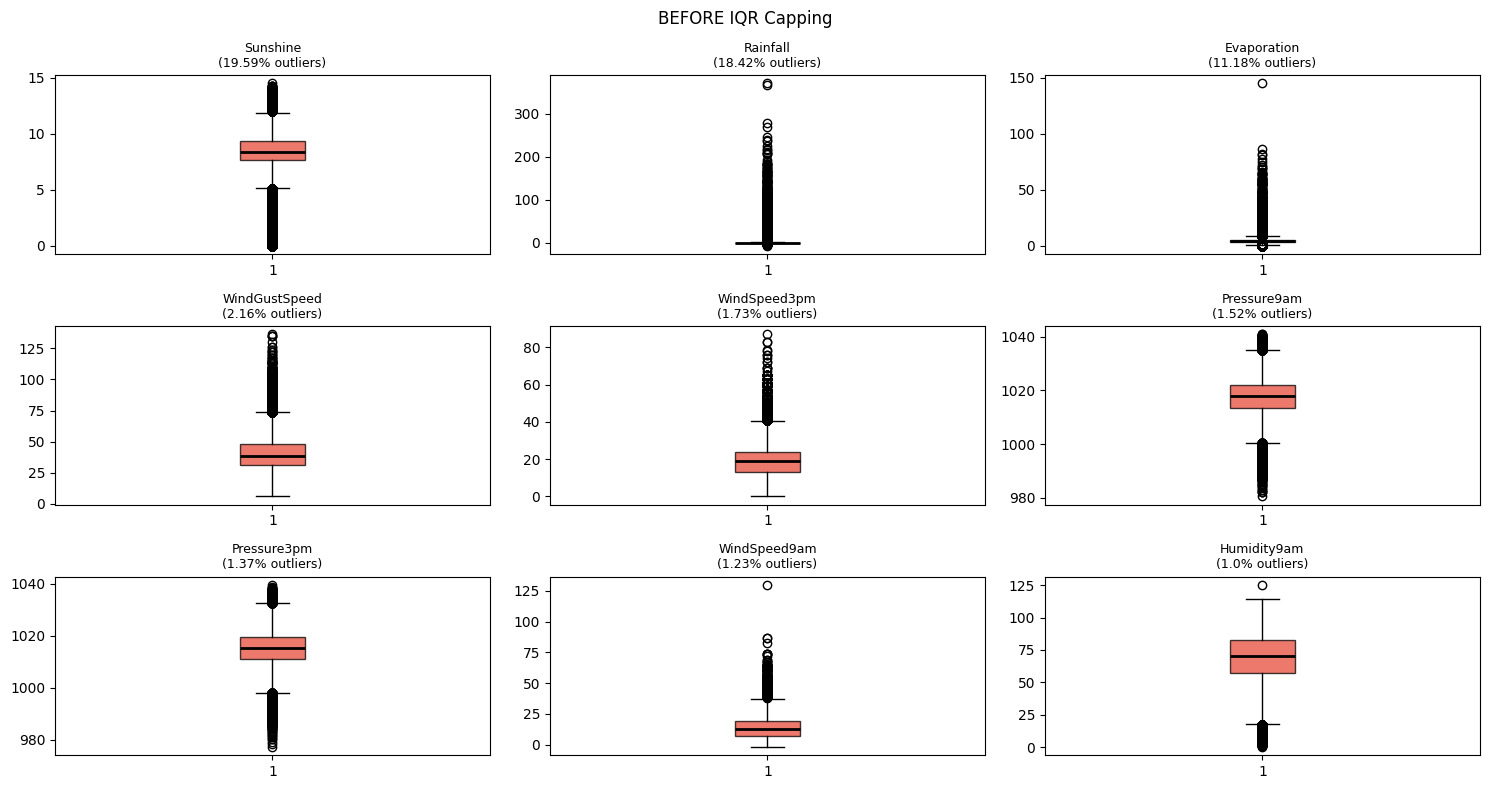

In [81]:
top_9= outlier_df.head(9).index.tolist()
fig , axes = plt.subplots(3,3,figsize=(15, 8))
axes =axes.flatten()

for i, col in enumerate(top_9):
    axes[i].boxplot(
        df[col].dropna(),
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor='#e74c3c', alpha=0.75),
        medianprops=dict(color='black', linewidth=2),
                   )
    pct = outlier_df.loc[col, 'Outlier Percentage']
    axes[i].set_title(f'{col}\n({pct}% outliers)', fontsize=9)

plt.suptitle('BEFORE IQR Capping')
plt.tight_layout()
plt.show()

In [82]:
#outlier capping 
new_out_count=[]
for col in num_cols:
    lo = outlier_df.loc[col, 'Lower Bound']
    hi = outlier_df.loc[col, 'Upper Bound']
    df[col] = df[col].clip(lower=lo, upper=hi)

    below =(df[col] < lo).sum()
    above = (df[col] > hi).sum()
    new_out_count.append({
        'Column':  col,
        'Lower Bound': round(lo, 2),
        'Upper Bound': round(hi, 2),
        'Number Below': below,
        'Number Above': above,
        'Total Outliers': above+below
        })

pd.DataFrame(new_out_count).set_index('Column')

,Lower Bound,Upper Bound,Number Below,Number Above,Total Outliers
Column,,,,,
MinTemp,-6.20,30.60,0,0,0
MaxTemp,2.45,43.65,0,0,0
Rainfall,-1.20,2.00,0,0,0
Evaporation,0.60,8.60,0,0,0
Sunshine,5.15,11.95,0,0,0
WindGustSpeed,5.50,73.50,0,0,0
WindSpeed9am,-11.00,37.00,0,0,0
WindSpeed3pm,-3.50,40.50,0,0,0
Humidity9am,18.00,122.00,0,0,0


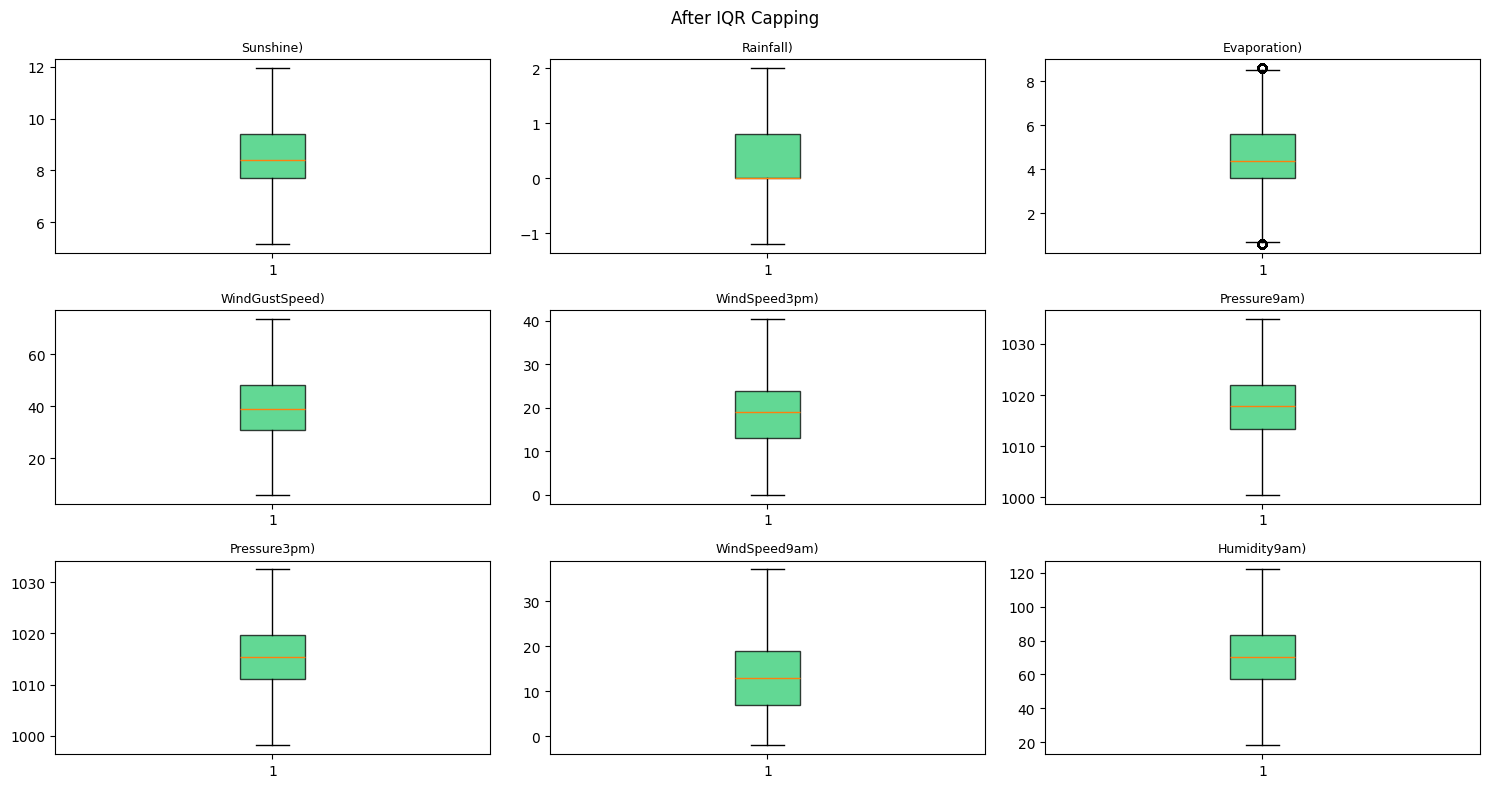

Total missing values: 0
Dataset shape (142193, 23)


In [83]:
fig , axes = plt.subplots(3,3,figsize=(15, 8))
axes =axes.flatten()

for i, col in enumerate(top_9):
    axes[i].boxplot(
        df[col].dropna(),
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor='#2ecc71', alpha=0.75),
                   )
    axes[i].set_title(f'{col})', fontsize=9)

plt.suptitle('After IQR Capping')
plt.tight_layout()
plt.show()

print(f'Total missing values: {df.isnull().sum().sum()}')
print(f'Dataset shape {df.shape}')

### Feature Transformation

**Skewness Check**

In [84]:
num_cols = df.select_dtypes(include=np.number).columns.tolist() 
skewness_before = df[num_cols].skew().sort_values(ascending=False) 

print("Skewness before transformation:\n", skewness_before)

Skewness before transformation:
 Rainfall         1.196811
WindGustSpeed    0.569991
WindSpeed9am     0.506716
WindSpeed3pm     0.403882
Evaporation      0.355429
Temp3pm          0.245383
MaxTemp          0.239219
Temp9am          0.086440
MinTemp          0.023848
Humidity3pm      0.023546
Pressure3pm      0.000300
Pressure9am     -0.026502
Sunshine        -0.069501
Humidity9am     -0.432404
Cloud3pm        -0.554813
Cloud9am        -0.748807
dtype: float64


**Log Transformation for Features that have absolute skewness > 1**

In [85]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')
df['Rainfall'] = pt.fit_transform(df[['Rainfall']])
skewness_after = df[num_cols].skew().sort_values(ascending=False) 


print("Skewness after transformation:\n", skewness_after)

Skewness after transformation:
 WindGustSpeed    0.569991
WindSpeed9am     0.506716
WindSpeed3pm     0.403882
Evaporation      0.355429
Temp3pm          0.245383
MaxTemp          0.239219
Temp9am          0.086440
MinTemp          0.023848
Humidity3pm      0.023546
Pressure3pm      0.000300
Pressure9am     -0.026502
Sunshine        -0.069501
Humidity9am     -0.432404
Cloud3pm        -0.554813
Cloud9am        -0.748807
Rainfall        -0.956391
dtype: float64


**Data Engineering: Handle Data Column**

I Created Season feature to understand seasonal patterns in rainfall

In [86]:
df['Date'] = pd.to_datetime(df['Date']) 

df['Year'] = df['Date'].dt.year 
df['Month'] = df['Date'].dt.month 
df['Day'] = df['Date'].dt.day 

df['Season'] = df['Month'].map({ 12:'Summer', 1:'Summer', 2:'Summer', 3:'Autumn', 4:'Autumn', 5:'Autumn', 6:'Winter', 7:'Winter', 8:'Winter', 9:'Spring', 10:'Spring', 11:'Spring' }) 

df.drop(columns=['Date'], inplace=True)

## Encoding Categorical Variables

In [87]:
cat_cols = df.select_dtypes(include='object').columns.tolist() 
print(f"Categorical columns: {cat_cols}")

Categorical columns: ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'RainTomorrow', 'Season']


In [88]:
ordinal_cats = ['RainToday', 'RainTomorrow'] 
nominal_cats = ['Location', 'Season', 'WindGustDir', 'WindDir9am', 'WindDir3pm']

In [89]:
from sklearn.preprocessing import LabelEncoder 
from sklearn.preprocessing import OneHotEncoder 

le = LabelEncoder() 
for col in ordinal_cats: df[col] = le.fit_transform(df[col].astype(str)) 

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore') 
encoded_df = pd.DataFrame(ohe.fit_transform(df[nominal_cats]), columns=ohe.get_feature_names_out(nominal_cats), index=df.index) 
df = pd.concat([df.drop(columns=nominal_cats), encoded_df], axis=1) 

print(df.dtypes)

MinTemp           float64
MaxTemp           float64
Rainfall          float64
Evaporation       float64
Sunshine          float64
                   ...   
WindDir3pm_SSW    float64
WindDir3pm_SW     float64
WindDir3pm_W      float64
WindDir3pm_WNW    float64
WindDir3pm_WSW    float64
Length: 123, dtype: object


## Feature Scaling

In [90]:
from sklearn.preprocessing import MinMaxScaler 

num_cols = df.select_dtypes(include=['int64', 'float64']).columns 

binary_cols = [col for col in df.columns if df[col].nunique() == 2]
continuous_cols = [col for col in num_cols if col not in binary_cols]

scaler = MinMaxScaler() 
df[continuous_cols] = scaler.fit_transform(df[continuous_cols])

df[num_cols].head()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,WindDir3pm_NNW,WindDir3pm_NW,WindDir3pm_S,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW
0,0.532609,0.496359,0.939293,0.475,0.477941,0.562963,0.564807,0.592593,0.509615,0.257821,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.369565,0.549757,0.853002,0.475,0.477941,0.562963,0.155213,0.543210,0.250000,0.284960,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.519022,0.564320,0.853002,0.475,0.477941,0.592593,0.539207,0.641975,0.192308,0.330192,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.418478,0.620146,0.853002,0.475,0.477941,0.266667,0.334410,0.222222,0.259615,0.203543,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.644022,0.724515,0.966163,0.475,0.477941,0.518519,0.232012,0.493827,0.615385,0.357331,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Handling Class Imbalance

In [91]:
X = df.drop("RainTomorrow", axis=1) 
y = df["RainTomorrow"]

In [92]:
from sklearn.model_selection import train_test_split 
from imblearn.over_sampling import SMOTE 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) 
smote = SMOTE(random_state=42) 
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [93]:
print(y_train.value_counts()) # Before SMOTE 
print(y_train_res.value_counts()) # After SMOTE

RainTomorrow
0    88252
1    25502
Name: count, dtype: int64
RainTomorrow
0    88252
1    88252
Name: count, dtype: int64
